In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

In [2]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

aum["date"] = pd.to_datetime(aum["date"])

sip["month"] = pd.to_datetime(sip["month"])

category["month"] = pd.to_datetime(category["month"])

folio["month"] = pd.to_datetime(folio["month"])

In [4]:
import kaleido
print(kaleido.__version__)

0.2.1


In [5]:
import plotly
print(plotly.__version__)

6.8.0


In [6]:
nav_plot = nav.merge(
    fund[["amfi_code","scheme_name"]],
    on="amfi_code"
)

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.10,
    annotation_text="2024 Correction"
)

fig.show()
fig.write_image("../reports/charts/nav_trend.png")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19384\1289837140.py:31: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image("../reports/charts/nav_trend.png")


## Insight 1

Most equity mutual funds witnessed sustained NAV appreciation during the 2023 market rally before moderate corrections in early 2024.

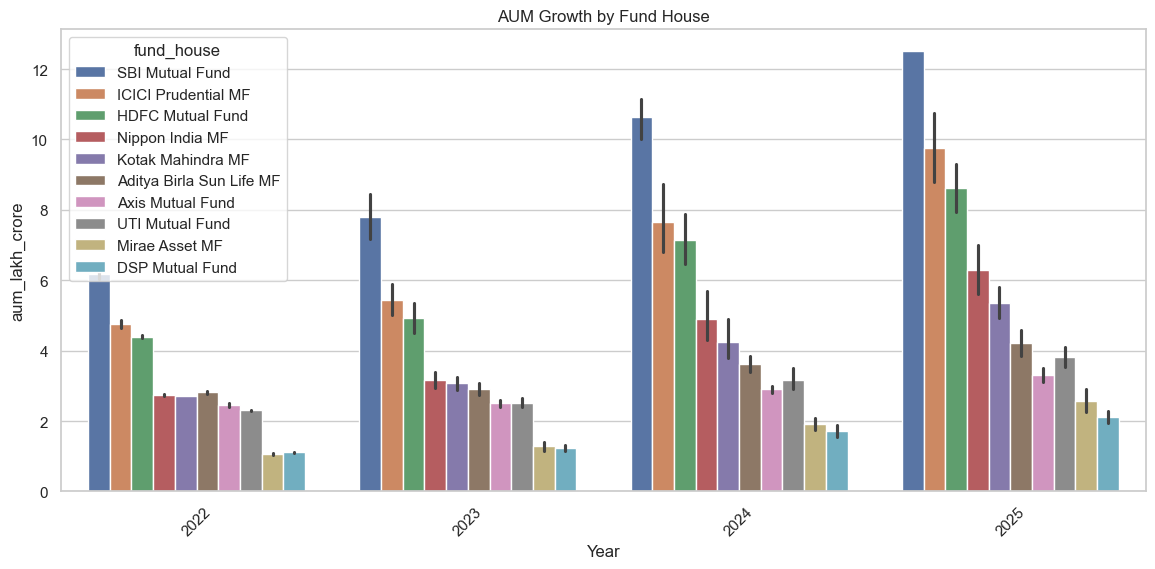

In [7]:
aum["Year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="Year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.xticks(rotation=45)
plt.savefig("../reports/charts/aum_growth.png", dpi=300, bbox_inches="tight")

plt.show()

SBI Mutual Fund consistently maintained the largest AUM across all years.

In [ ]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows"
)

fig.add_annotation(
    x="2025-12",
    y=31002,
    text="₹31,002 Cr All-Time High",
    showarrow=True
)
fig.write_image("../reports/charts/sip_trend.png")
fig.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19384\3759500977.py:15: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image("../reports/sip_trend.png")


Monthly SIP inflows steadily increased and crossed ₹31,000 crore in December 2025.

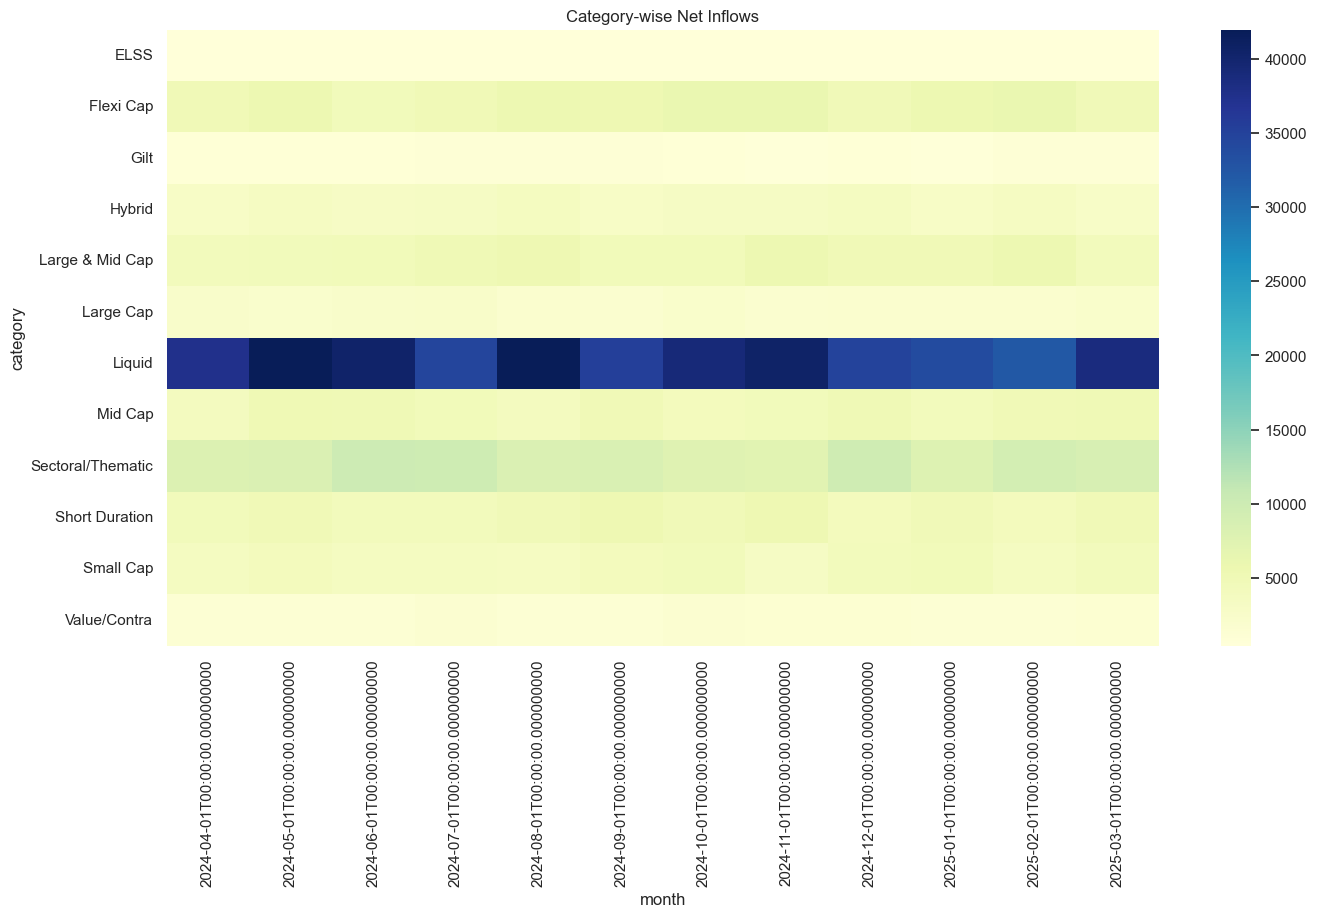

In [9]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows")
plt.savefig("../reports/charts/cat_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

Liquid funds consistently attracted the highest monthly net inflows, while Sectoral/Thematic funds showed moderate investor interest and most other categories maintained relatively stable inflow patterns throughout the analysis period.

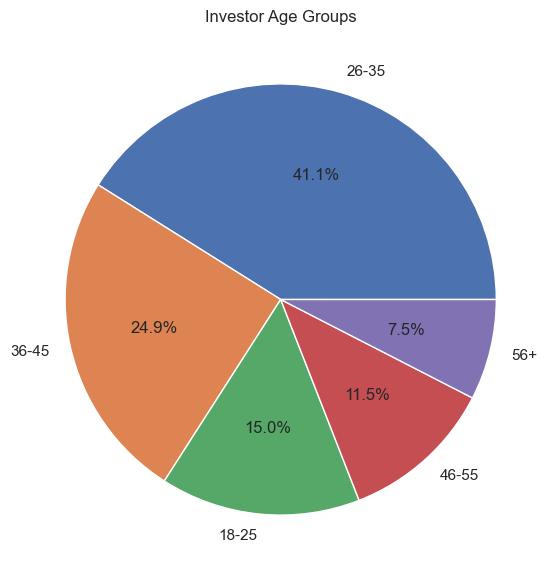

In [19]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.ylabel("")
plt.title("Investor Age Groups")
plt.savefig("../reports/charts/age.png", dpi=300, bbox_inches="tight")
plt.show()


Most investors belonged to the 26–35 age group.

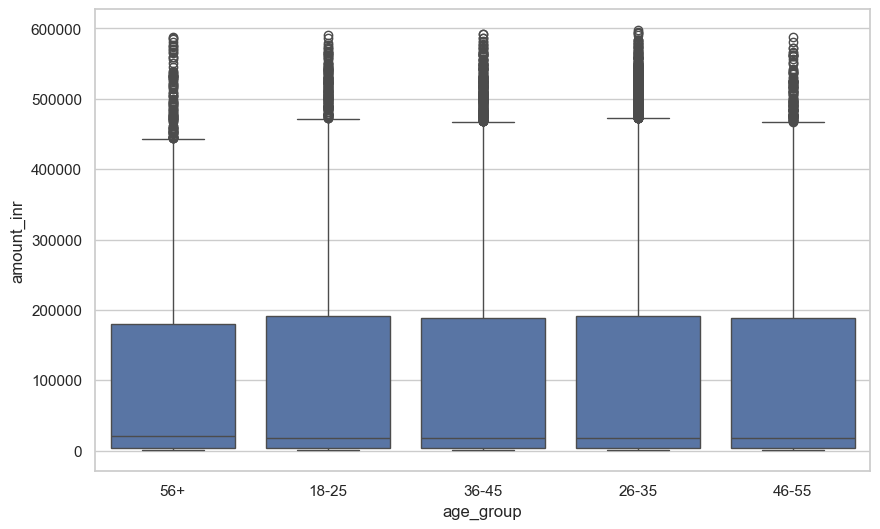

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)
plt.savefig("../reports/charts/sip_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()


SIP investment patterns are consistent across all age groups, although each group includes several high-value investors contributing significantly larger amounts than the average.

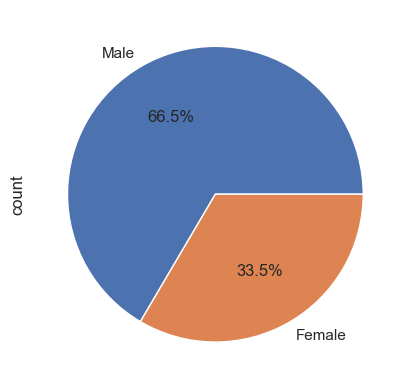

In [12]:
transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.savefig("../reports/charts/gender_split.png", dpi=300, bbox_inches="tight")
plt.show()

 Male investors constitute a larger proportion of the investor base than female investors, although both groups contribute significantly to overall mutual fund participation.



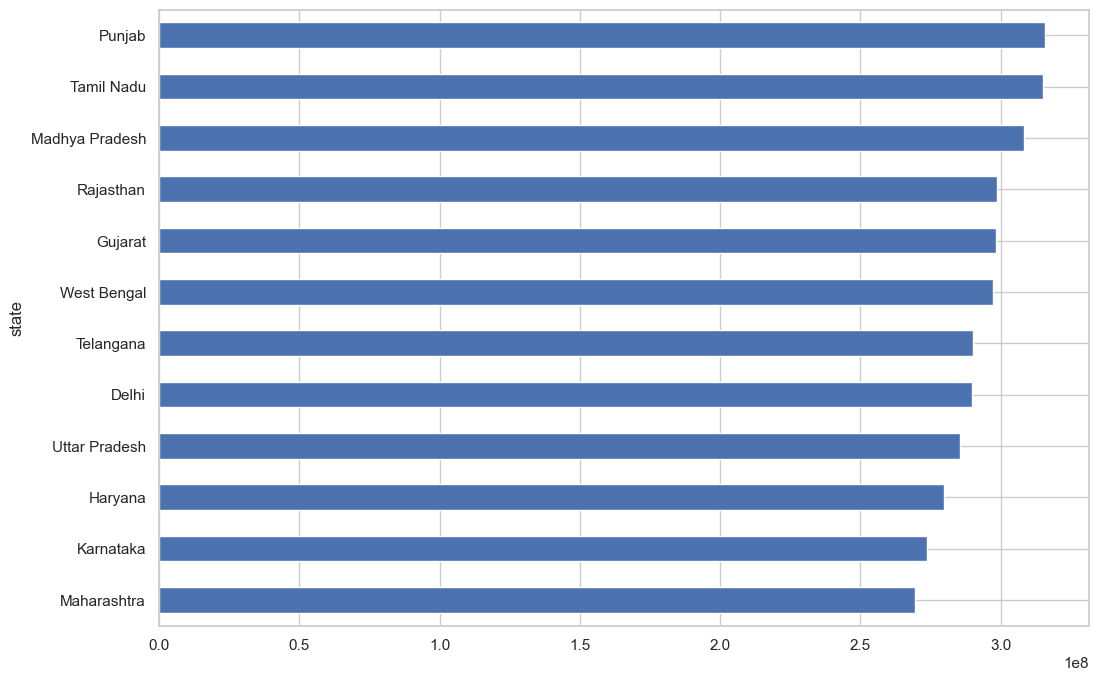

In [13]:
state = (
transactions
.groupby("state")["amount_inr"]
.sum()
.sort_values()
)

state.plot(
    kind="barh",
    figsize=(12,8)
)
plt.savefig("../reports/charts/state_trans.png", dpi=300, bbox_inches="tight")

plt.show()

Punjab recorded the highest SIP investment amount, while investment participation remained relatively balanced across the other states, reflecting widespread geographic adoption of mutual fund investing.

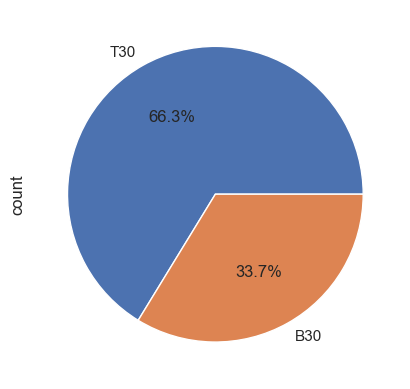

In [14]:
transactions["city_tier"].value_counts().plot(
kind="pie",
autopct="%1.1f%%"
)
plt.savefig("../reports/charts/city_tier.png", dpi=300, bbox_inches="tight")

plt.show()

T30 cities contributed the majority of investments.

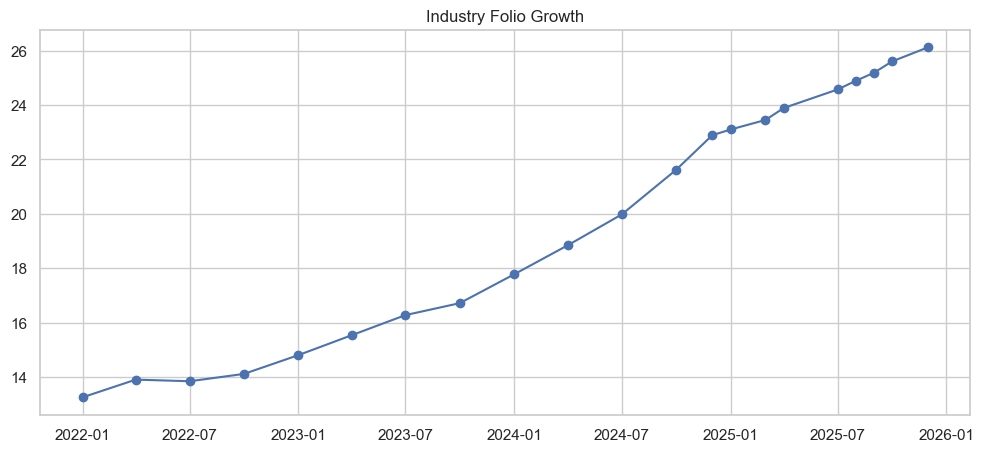

In [15]:
plt.figure(figsize=(12,5))

plt.plot(
folio["month"],
folio["total_folios_crore"],
marker="o"
)

plt.title("Industry Folio Growth")
plt.savefig("../reports/charts/folio_growth.png", dpi=300, bbox_inches="tight")

plt.show()

Industry folios nearly doubled between 2022 and 2025.

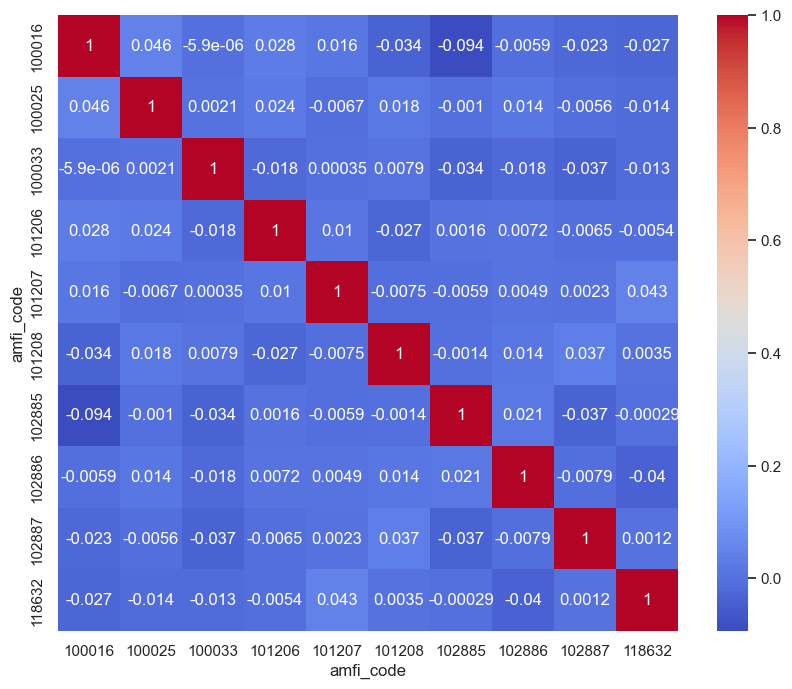

In [16]:
top10 = nav["amfi_code"].unique()[:10]

corr = nav[
nav["amfi_code"].isin(top10)
]

pivot = corr.pivot(
index="date",
columns="amfi_code",
values="nav"
)

returns = pivot.pct_change()

plt.figure(figsize=(10,8))

sns.heatmap(
returns.corr(),
annot=True,
cmap="coolwarm"
)
plt.savefig("../reports/charts/corr_mat.png", dpi=300, bbox_inches="tight")

plt.show()

Most selected mutual funds exhibit weak correlations in their daily returns, indicating relatively independent performance and supporting the benefits of portfolio diversification.

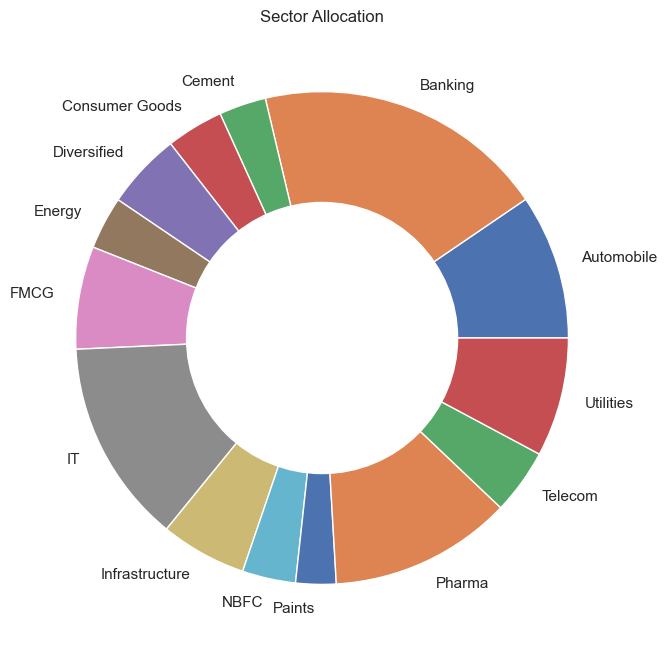

In [17]:
sector = (
holdings
.groupby("sector")["weight_pct"]
.sum()
)

plt.figure(figsize=(8,8))

plt.pie(
sector,
labels=sector.index
)

centre = plt.Circle((0,0),0.55,fc='white')

plt.gca().add_artist(centre)

plt.title("Sector Allocation")
plt.savefig("../reports/charts/sector_alloc.png", dpi=300, bbox_inches="tight")

plt.show()

Banking and IT formed the largest portfolio allocations.